# VAR Modeling – Dynamic Pricing in the Airline Industry


## 0. Import thư viện & Tải dữ liệu

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

# Tải dữ liệu
df = pd.read_csv('data/master_data_merged.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()}  →  {df["Date"].max().date()}')
df.head()

Shape: (37, 10)
Date range: 2019-03-01  →  2019-06-27


,Date,Median_Price,Brent_Oil_Price,USD_INR_Exchange,Median_Price_diff,Median_Price_logret,Brent_Oil_Price_diff,Brent_Oil_Price_logret,USD_INR_Exchange_diff,USD_INR_Exchange_logret
0,2019-03-01,23533.0000,65.0700,70.8160,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-03-03,14973.0000,65.0700,70.8160,-8560.0000,-0.4522,0.0000,0.0000,0.0000,0.0000
2,2019-03-06,15078.0000,65.9900,70.7425,105.0000,0.0070,0.9200,0.0140,-0.0735,-0.0010
3,2019-03-09,13843.0000,65.7400,70.4875,-1235.0000,-0.0855,-0.2500,-0.0038,-0.2550,-0.0036
4,2019-03-15,5784.5000,67.1600,69.3373,-8058.5000,-0.8726,1.4200,0.0214,-1.1502,-0.0165


## 1. Chuẩn bị biến – Kiểm định tính dừng (ADF Test)


In [2]:
# Chọn 3 biến chính: Giá vé, Giá dầu, Tỷ giá
VARS_LEVEL = ['Median_Price', 'Brent_Oil_Price', 'USD_INR_Exchange']
VARS_DIFF  = ['Median_Price_diff', 'Brent_Oil_Price_diff', 'USD_INR_Exchange_diff']

def adf_summary(series: pd.Series, name: str) -> dict:
    """Chạy ADF test và trả về kết quả dạng dict."""
    series_clean = series.dropna()
    stat, p, _, _, crit, _ = adfuller(series_clean, autolag='AIC')
    return {
        'Variable': name,
        'ADF Statistic': stat,
        'p-value': p,
        'Critical 5%': crit['5%'],
        'Stationary (p<0.05)': 'YES ✓' if p < 0.05 else 'NO ✗'
    }

rows = []
for col in VARS_LEVEL:
    rows.append(adf_summary(df[col], col + ' (level)'))
for col in VARS_DIFF:
    rows.append(adf_summary(df[col].dropna(), col + ' (diff)'))

adf_df = pd.DataFrame(rows)
print('=== ADF Stationarity Test ===')
adf_df

=== ADF Stationarity Test ===


,Variable,ADF Statistic,p-value,Critical 5%,Stationary (p<0.05)
0,Median_Price (level),-5.0975,0.0000,-2.9460,YES ✓
1,Brent_Oil_Price (level),-1.3748,0.5943,-2.9460,NO ✗
2,USD_INR_Exchange (level),-2.9135,0.0438,-2.9460,YES ✓
3,Median_Price_diff (diff),-3.7424,0.0036,-2.9541,YES ✓
4,Brent_Oil_Price_diff (diff),-5.8810,0.0000,-2.9485,YES ✓
5,USD_INR_Exchange_diff (diff),-4.8789,0.0000,-2.9512,YES ✓


In [3]:
# Sử dụng cột diff (sai phân bậc 1) – loại bỏ NaN đầu tiên
var_data = df[['Date'] + VARS_DIFF].dropna().reset_index(drop=True)
var_data = var_data.rename(columns={
    'Median_Price_diff'      : 'dPrice',
    'Brent_Oil_Price_diff'   : 'dOil',
    'USD_INR_Exchange_diff'  : 'dFX'
})

print(f'VAR dataset shape: {var_data.shape}')
var_data.head()

VAR dataset shape: (36, 4)


,Date,dPrice,dOil,dFX
0,2019-03-03,-8560.0000,0.0000,0.0000
1,2019-03-06,105.0000,0.9200,-0.0735
2,2019-03-09,-1235.0000,-0.2500,-0.2550
3,2019-03-15,-8058.5000,1.4200,-1.1502
4,2019-03-18,-288.5000,0.3800,-0.3843


## 2. Kiểm định Nhân quả Granger (Granger Causality)

**Giả thuyết H₀:** Biến X *không* giúp dự báo biến Y (không có quan hệ nhân quả).  
Nếu **p-value < 0.05** → bác bỏ H₀ → X có quan hệ nhân quả Granger với Y.

In [4]:
MAX_LAG = 5

def granger_table(data: pd.DataFrame, cause: str, effect: str, maxlag: int) -> pd.DataFrame:
    """Chạy Granger causality test và trả về bảng p-value theo lag."""
    # statsmodels yêu cầu [effect, cause]
    test_data = data[[effect, cause]].dropna()
    result = grangercausalitytests(test_data, maxlag=maxlag, verbose=False)
    rows = []
    for lag, res in result.items():
        p_f = res[0]['ssr_ftest'][1]     # F-test p-value
        p_chi2 = res[0]['ssr_chi2test'][1]  # Chi2 p-value
        rows.append({
            'Lag': lag,
            'F-test p-value': round(p_f, 4),
            'Chi2 p-value': round(p_chi2, 4),
            'Significant (5%)': '✓' if p_f < 0.05 else '✗'
        })
    return pd.DataFrame(rows)

# Test 1: Giá dầu → Giá vé
print('=' * 55)
print('Granger Causality:  dOil  →  dPrice (Giá dầu → Giá vé)')
print('=' * 55)
gc1 = granger_table(var_data, cause='dOil', effect='dPrice', maxlag=MAX_LAG)
display(gc1)

# Test 2: Tỷ giá → Giá vé
print('\n' + '=' * 55)
print('Granger Causality:  dFX   →  dPrice (Tỷ giá → Giá vé)')
print('=' * 55)
gc2 = granger_table(var_data, cause='dFX', effect='dPrice', maxlag=MAX_LAG)
display(gc2)

Granger Causality:  dOil  →  dPrice (Giá dầu → Giá vé)


,Lag,F-test p-value,Chi2 p-value,Significant (5%)
0,1,0.7791,0.7674,✗
1,2,0.6055,0.5496,✗
2,3,0.6878,0.5954,✗
3,4,0.7689,0.6405,✗
4,5,0.8872,0.7646,✗



Granger Causality:  dFX   →  dPrice (Tỷ giá → Giá vé)


,Lag,F-test p-value,Chi2 p-value,Significant (5%)
0,1,0.1644,0.1366,✗
1,2,0.4733,0.4066,✗
2,3,0.3473,0.2231,✗
3,4,0.1565,0.0370,✗
4,5,0.1117,0.0067,✗


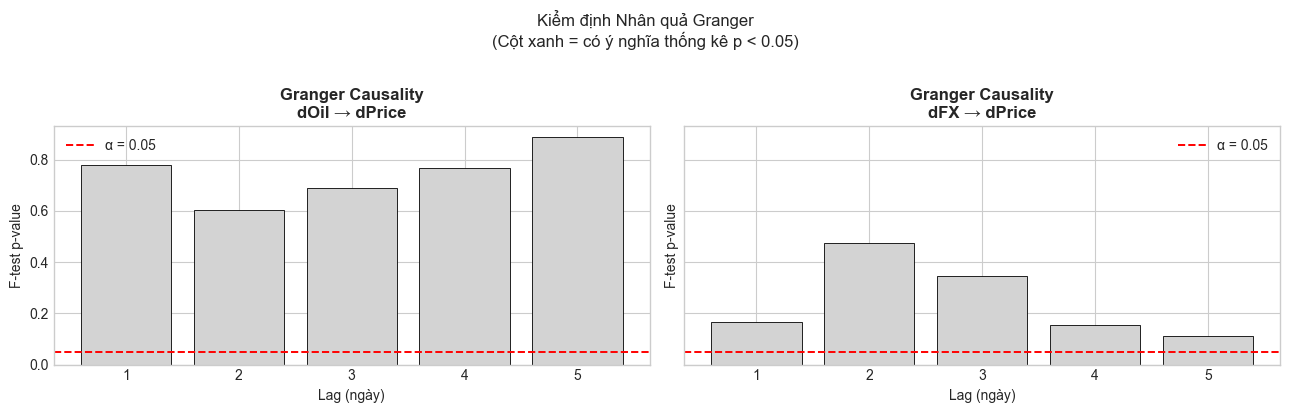

In [5]:
# Trực quan hoá p-value theo lag
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, gc_df, title in zip(
    axes,
    [gc1, gc2],
    ['dOil → dPrice', 'dFX → dPrice']
):
    colors = ['steelblue' if p < 0.05 else 'lightgray' for p in gc_df['F-test p-value']]
    ax.bar(gc_df['Lag'], gc_df['F-test p-value'], color=colors, edgecolor='black', linewidth=0.6)
    ax.axhline(0.05, color='red', linestyle='--', linewidth=1.4, label='α = 0.05')
    ax.set_title(f'Granger Causality\n{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Lag (ngày)')
    ax.set_ylabel('F-test p-value')
    ax.set_xticks(gc_df['Lag'])
    ax.legend()

plt.suptitle('Kiểm định Nhân quả Granger\n(Cột xanh = có ý nghĩa thống kê p < 0.05)', y=1.02)
plt.tight_layout()
plt.savefig('granger_causality.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Chia tập Train / Test (Chronological Split 80/20)

Tổng số quan sát  : 36
Train (80%)        : 28 obs  (2019-03-03 → 2019-06-03)
Test  (20%)         : 8 obs  (2019-06-06 → 2019-06-27)


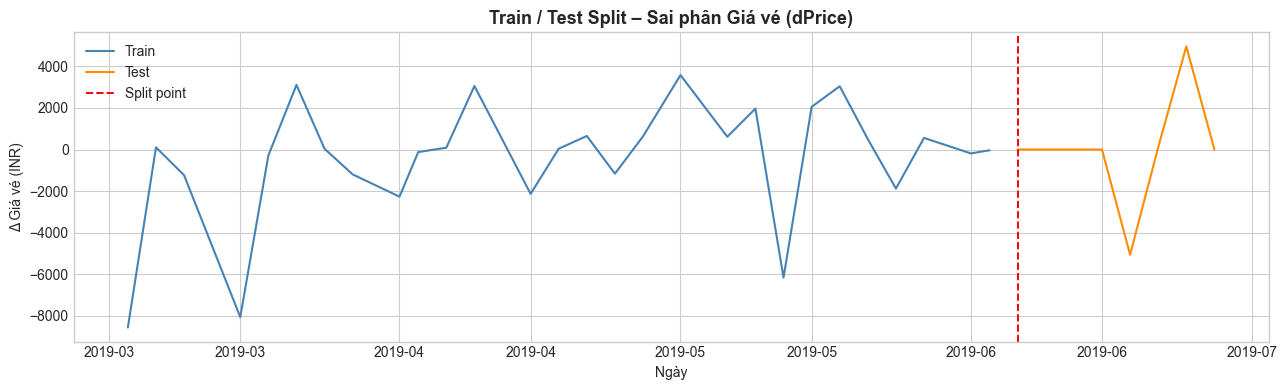

In [6]:
SPLIT_RATIO = 0.80
n = len(var_data)
split_idx = int(n * SPLIT_RATIO)

train_df = var_data.iloc[:split_idx].copy()
test_df  = var_data.iloc[split_idx:].copy()

print(f'Tổng số quan sát  : {n}')
print(f'Train ({SPLIT_RATIO*100:.0f}%)        : {len(train_df)} obs  '
      f'({train_df["Date"].min().date()} → {train_df["Date"].max().date()})')
print(f'Test  ({(1-SPLIT_RATIO)*100:.0f}%)         : {len(test_df)} obs  '
      f'({test_df["Date"].min().date()} → {test_df["Date"].max().date()})')

# Visualize split
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_df['Date'], train_df['dPrice'], color='steelblue', label='Train')
ax.plot(test_df['Date'],  test_df['dPrice'],  color='darkorange', label='Test')
ax.axvline(test_df['Date'].iloc[0], color='red', linestyle='--', linewidth=1.4, label='Split point')
ax.set_title('Train / Test Split – Sai phân Giá vé (dPrice)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ngày')
ax.set_ylabel('Δ Giá vé (INR)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Mô hình VAR – Tìm Lag Tối Ưu (AIC / BIC / HQIC)

In [7]:
FEATURES = ['dPrice', 'dOil', 'dFX']
train_df_var = train_df[FEATURES].reset_index(drop=True)
train_vals   = train_df_var.values

# statsmodels yêu cầu: maxlags <= floor((nobs - 1) / (nvars + 1))
n_obs, n_vars = train_vals.shape
safe_maxlags = max(1, int((n_obs - 1) / (n_vars + 1)))
MAX_LAGS_SEARCH = min(6, safe_maxlags)
print(f'Train obs: {n_obs} | n_vars: {n_vars} | maxlags tối đa an toàn: {MAX_LAGS_SEARCH}')

model_selector = VAR(train_df_var)   # truyền DataFrame để giữ tên cột
lag_results = model_selector.select_order(maxlags=MAX_LAGS_SEARCH)

# Bảng tiêu chí thông tin
ic_df = pd.DataFrame({
    'Lag' : range(len(lag_results.ics['aic'])),
    'AIC' : lag_results.ics['aic'],
    'BIC' : lag_results.ics['bic'],
    'HQIC': lag_results.ics['hqic'],
})

best_aic  = int(lag_results.selected_orders['aic'])
best_bic  = int(lag_results.selected_orders['bic'])
best_hqic = int(lag_results.selected_orders['hqic'])

print(f'Lag tối ưu theo AIC : {best_aic}')
print(f'Lag tối ưu theo BIC : {best_bic}')
print(f'Lag tối ưu theo HQIC: {best_hqic}')
ic_df

Train obs: 28 | n_vars: 3 | maxlags tối đa an toàn: 6
Lag tối ưu theo AIC : 6
Lag tối ưu theo BIC : 6
Lag tối ưu theo HQIC: 6


,Lag,AIC,BIC,HQIC
0,0,14.7409,14.8897,14.7760
1,1,15.1133,15.7084,15.2535
2,2,14.4968,15.5383,14.7421
3,3,14.6800,16.1678,15.0305
4,4,14.4326,16.3667,14.8882
5,5,14.1334,16.5138,14.6941
6,6,8.0273,10.8541,8.6932


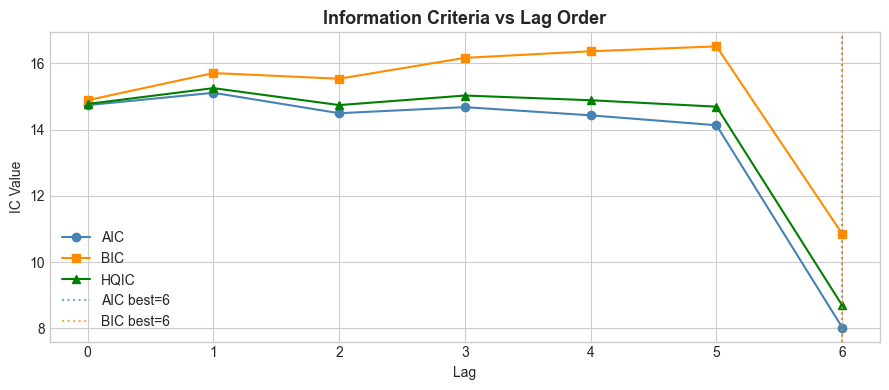

In [8]:
# Trực quan hoá IC theo lag
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ic_df['Lag'], ic_df['AIC'],  marker='o', label='AIC',  color='steelblue')
ax.plot(ic_df['Lag'], ic_df['BIC'],  marker='s', label='BIC',  color='darkorange')
ax.plot(ic_df['Lag'], ic_df['HQIC'], marker='^', label='HQIC', color='green')
ax.axvline(best_aic, color='steelblue', linestyle=':', alpha=0.7, label=f'AIC best={best_aic}')
ax.axvline(best_bic, color='darkorange', linestyle=':', alpha=0.7, label=f'BIC best={best_bic}')
ax.set_title('Information Criteria vs Lag Order', fontsize=13, fontweight='bold')
ax.set_xlabel('Lag')
ax.set_ylabel('IC Value')
ax.set_xticks(ic_df['Lag'])
ax.legend()
plt.tight_layout()
plt.savefig('var_lag_selection.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Fit Mô hình VAR trên tập Train

In [9]:
# Dùng lag theo AIC; nếu AIC=0 fallback sang BIC
OPTIMAL_LAG = best_aic if best_aic > 0 else max(best_bic, 1)
print(f'>>> Sử dụng lag = {OPTIMAL_LAG} để fit mô hình VAR')

var_model = VAR(train_df_var)   # truyền DataFrame để giữ tên cột
var_fit   = var_model.fit(maxlags=OPTIMAL_LAG, ic=None)   # fit cố định lag

print(var_fit.summary())

>>> Sử dụng lag = 6 để fit mô hình VAR
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Apr, 2026
Time:                     15:52:49
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    10.8541
Nobs:                     22.0000    HQIC:                   8.69319
Log likelihood:          -124.950    FPE:                    43929.6
AIC:                      8.02728    Det(Omega_mle):         6786.93
--------------------------------------------------------------------
Results for equation dPrice
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const            98.100494       439.440388            0.223           0.823
L1.dPrice        -0.393537         0.423589           -0.929           0.353
L1.dOil        -126.758423       456

## 6. Phân tích Phản ứng Xung (IRF – Impulse Response Function)


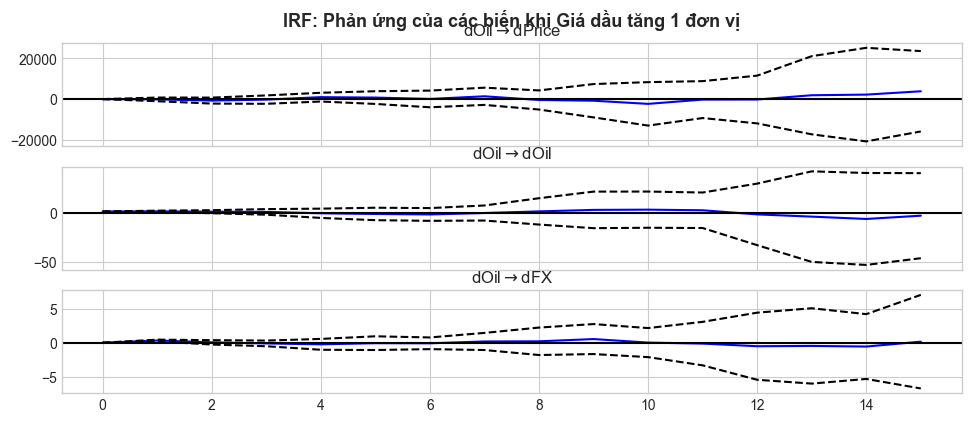

In [10]:
PERIODS = 15   # quan sát phản ứng trong 15 ngày

irf = var_fit.irf(periods=PERIODS)

# --- Biểu đồ IRF tổng quát (built-in) ---
fig_irf = irf.plot(
    impulse='dOil',
    figsize=(10, 4),
    subplot_params=dict(hspace=0.6)
)
fig_irf.suptitle('IRF: Phản ứng của các biến khi Giá dầu tăng 1 đơn vị',
                 fontsize=13, fontweight='bold', y=1.01)
plt.savefig('irf_oil_shock.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# --- IRF tuỳ chỉnh: Chỉ hiển thị phản ứng của dPrice ---
# Thứ tự biến trong VAR: ['dPrice', 'dOil', 'dFX']
VAR_NAMES = FEATURES   # ['dPrice', 'dOil', 'dFX']

irf_vals     = irf.irfs           # shape: (periods+1, nvars, nvars)
irf_lower    = irf.cum_effect_lower if hasattr(irf, 'cum_effect_lower') else None
irf_upper    = irf.cum_effect_upper if hasattr(irf, 'cum_effect_upper') else None

price_idx = VAR_NAMES.index('dPrice')
oil_idx   = VAR_NAMES.index('dOil')
fx_idx    = VAR_NAMES.index('dFX')

horizon = np.arange(PERIODS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, shock_idx, shock_label, color in zip(
    axes,
    [oil_idx, fx_idx],
    ['Shock: Giá dầu (dOil)', 'Shock: Tỷ giá (dFX)'],
    ['steelblue', 'darkorange']
):
    response = irf_vals[:, price_idx, shock_idx]
    ax.plot(horizon, response, color=color, linewidth=2, marker='o', markersize=4)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    # Vùng bootstrap CI nếu có
    try:
        irf_boot = var_fit.irf(periods=PERIODS)
        err_bands = irf_boot.plot(impulse=VAR_NAMES[shock_idx], response='dPrice')
        plt.close('all')   # đóng plot tự động; chỉ lấy dữ liệu
    except Exception:
        pass

    # Đánh dấu ngày đầu tiên phản ứng vượt 0
    crossings = np.where(np.diff(np.sign(response)))[0]
    if len(crossings) > 0:
        first_cross = crossings[0] + 1
        ax.axvline(first_cross, color='red', linestyle=':', linewidth=1.2,
                   label=f'Phản ứng đổi chiều t={first_cross}')
        ax.legend(fontsize=9)

    ax.set_title(f'Phản ứng của dPrice\n{shock_label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Ngày sau shock')
    ax.set_ylabel('Phản ứng (Δ Giá vé)')
    ax.set_xticks(horizon)

plt.suptitle('Impulse Response Function (IRF)\nPhản ứng của Giá vé trước cú sốc Giá dầu / Tỷ giá',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('irf_custom.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- IRF: Phản ứng của dPrice theo ngày ---')
irf_table = pd.DataFrame({
    'Horizon': horizon,
    'Response to dOil Shock': irf_vals[:, price_idx, oil_idx].round(2),
    'Response to dFX Shock' : irf_vals[:, price_idx, fx_idx].round(2),
})
irf_table

<Figure size 640x480 with 0 Axes>


--- IRF: Phản ứng của dPrice theo ngày ---


,Horizon,Response to dOil Shock,Response to dFX Shock
0,0,0.0000,0.0000
1,1,-126.7600,167.5500
2,2,-716.1000,3726.0900
3,3,-238.3500,2304.0100
4,4,963.6900,-3034.0500
5,5,751.8600,-9400.1900
6,6,88.0600,7086.9600
7,7,1381.0300,-2185.9000
8,8,-419.1300,-1661.9900
9,9,-780.6800,-661.5000


### 6.1 Tích lũy phản ứng (Cumulative IRF)

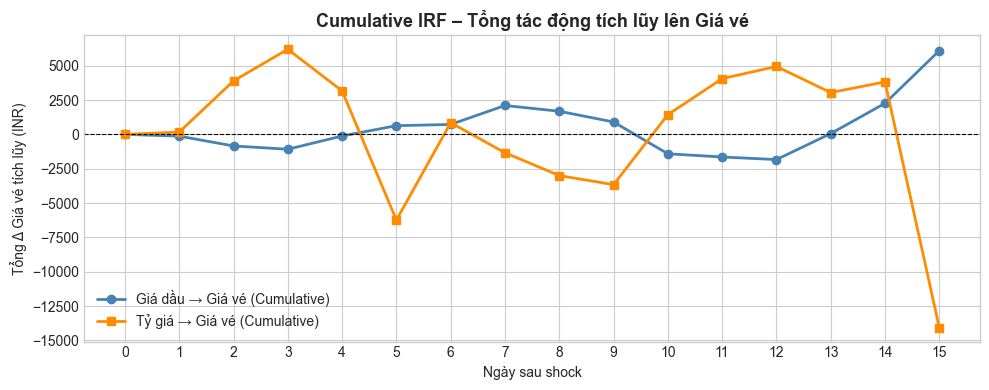

In [12]:
cirf_oil = np.cumsum(irf_vals[:, price_idx, oil_idx])
cirf_fx  = np.cumsum(irf_vals[:, price_idx, fx_idx])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(horizon, cirf_oil, marker='o', color='steelblue',   linewidth=2, label='Giá dầu → Giá vé (Cumulative)')
ax.plot(horizon, cirf_fx,  marker='s', color='darkorange',  linewidth=2, label='Tỷ giá → Giá vé (Cumulative)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative IRF – Tổng tác động tích lũy lên Giá vé', fontsize=13, fontweight='bold')
ax.set_xlabel('Ngày sau shock')
ax.set_ylabel('Tổng Δ Giá vé tích lũy (INR)')
ax.set_xticks(horizon)
ax.legend()
plt.tight_layout()
plt.savefig('cumulative_irf.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Dự báo trên tập Test & Đánh giá (RMSE, MAE)

In [13]:
n_test   = len(test_df)
lag_vals = train_vals[-OPTIMAL_LAG:]   # giá trị khởi động (seed) cho dự báo

# Dự báo bước đi rolling (1-step-ahead) để sát thực tế nhất
predictions_diff = []
history = train_vals.tolist()

for i in range(n_test):
    seed = np.array(history[-OPTIMAL_LAG:])
    fc   = var_fit.forecast(seed, steps=1)[0]   # [dPrice, dOil, dFX]
    predictions_diff.append(fc)
    history.append(test_df[FEATURES].values[i])  # thêm giá trị thực

pred_arr = np.array(predictions_diff)  # (n_test, 3)

# ---------- Chuyển sai phân → mức giá tuyệt đối ----------
# Lấy mức giá cuối của train làm gốc
last_train_price = df.loc[df['Date'] == train_df['Date'].iloc[-1], 'Median_Price'].values
if len(last_train_price) == 0:
    # Fallback: tính từ index
    train_end_idx = var_data.index[split_idx - 1]
    last_train_price = df.loc[train_end_idx + 1, 'Median_Price']
else:
    last_train_price = last_train_price[0]

# Reconstruct giá tuyệt đối từ sai phân
pred_price_abs = np.cumsum(pred_arr[:, 0]) + last_train_price

# Lấy giá thực trên tập test (level)
test_dates = test_df['Date'].values
actual_price_abs = df.loc[df['Date'].isin(test_df['Date']), 'Median_Price'].values

# Căn chỉnh độ dài nếu cần
min_len = min(len(pred_price_abs), len(actual_price_abs))
pred_price_abs   = pred_price_abs[:min_len]
actual_price_abs = actual_price_abs[:min_len]
test_dates       = test_dates[:min_len]

# Đánh giá
rmse = np.sqrt(mean_squared_error(actual_price_abs, pred_price_abs))
mae  = mean_absolute_error(actual_price_abs, pred_price_abs)
mape = np.mean(np.abs((actual_price_abs - pred_price_abs) / actual_price_abs)) * 100

print('=' * 45)
print(f'  RMSE : {rmse:>10,.2f} INR')
print(f'  MAE  : {mae:>10,.2f} INR')
print(f'  MAPE : {mape:>10.2f} %')
print('=' * 45)

  RMSE :   5,194.71 INR
  MAE  :   4,671.78 INR
  MAPE :      57.13 %


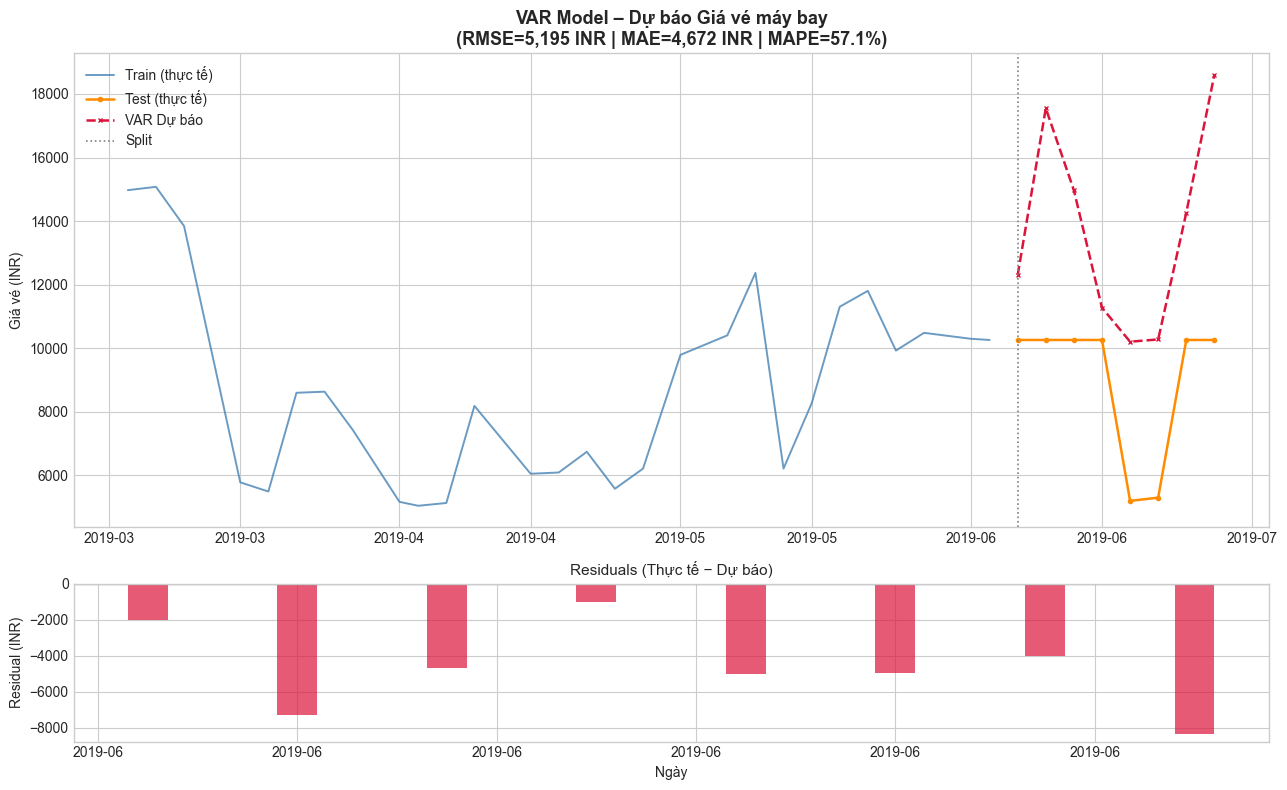

In [14]:
# Visualize dự báo vs thực tế
fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [3, 1]})

# --- Plot 1: Toàn bộ chuỗi + dự báo ---
ax1 = axes[0]
train_price = df.loc[df['Date'].isin(train_df['Date']), 'Median_Price']
train_dates = df.loc[df['Date'].isin(train_df['Date']), 'Date']

ax1.plot(train_dates, train_price, color='steelblue', linewidth=1.4, label='Train (thực tế)', alpha=0.8)
ax1.plot(test_dates,  actual_price_abs, color='darkorange', linewidth=1.8,
         label='Test (thực tế)', marker='o', markersize=3)
ax1.plot(test_dates,  pred_price_abs,   color='crimson',     linewidth=1.8,
         linestyle='--', label='VAR Dự báo', marker='x', markersize=3)
ax1.axvline(pd.Timestamp(test_dates[0]), color='gray', linestyle=':', linewidth=1.2, label='Split')
ax1.set_title(f'VAR Model – Dự báo Giá vé máy bay\n(RMSE={rmse:,.0f} INR | MAE={mae:,.0f} INR | MAPE={mape:.1f}%)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Giá vé (INR)')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- Plot 2: Residuals ---
ax2 = axes[1]
residuals = actual_price_abs - pred_price_abs
ax2.bar(test_dates, residuals,
        color=['steelblue' if r >= 0 else 'crimson' for r in residuals],
        alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Residuals (Thực tế − Dự báo)', fontsize=11)
ax2.set_xlabel('Ngày')
ax2.set_ylabel('Residual (INR)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('var_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Tổng kết Kết quả

In [15]:
summary = pd.DataFrame([
    {'Hạng mục': 'Số quan sát (sau diff)',   'Giá trị': f'{n}'},
    {'Hạng mục': 'Train size',               'Giá trị': f'{len(train_df)} obs'},
    {'Hạng mục': 'Test size',                'Giá trị': f'{len(test_df)} obs'},
    {'Hạng mục': 'Lag tối ưu (AIC)',         'Giá trị': str(best_aic)},
    {'Hạng mục': 'Lag tối ưu (BIC)',         'Giá trị': str(best_bic)},
    {'Hạng mục': 'RMSE (giá tuyệt đối)',     'Giá trị': f'{rmse:,.2f} INR'},
    {'Hạng mục': 'MAE  (giá tuyệt đối)',     'Giá trị': f'{mae:,.2f} INR'},
    {'Hạng mục': 'MAPE',                     'Giá trị': f'{mape:.2f} %'},
    {'Hạng mục': 'Granger dOil→dPrice (lag 1)', 'Giá trị': f'p={gc1["F-test p-value"].iloc[0]}'},
    {'Hạng mục': 'Granger dFX→dPrice (lag 1)',  'Giá trị': f'p={gc2["F-test p-value"].iloc[0]}'},
])

print('\n=== KẾT QUẢ TỔNG QUAN ===')
summary.style.set_caption('VAR Model Summary').set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}]
)


=== KẾT QUẢ TỔNG QUAN ===


,Hạng mục,Giá trị
0,Số quan sát (sau diff),36
1,Train size,28 obs
2,Test size,8 obs
3,Lag tối ưu (AIC),6
4,Lag tối ưu (BIC),6
5,RMSE (giá tuyệt đối),"5,194.71 INR"
6,MAE (giá tuyệt đối),"4,671.78 INR"
7,MAPE,57.13 %
8,Granger dOil→dPrice (lag 1),p=0.7791
9,Granger dFX→dPrice (lag 1),p=0.1644


---
# PHẦN II — XGBoost Modeling
**Mục tiêu:** Sử dụng kết quả IRF từ mô hình VAR để xác định độ trễ (lag) tối ưu,
sau đó xây dựng mô hình XGBoost dự báo giá vé máy bay và so sánh hiệu suất với VAR.

## Bước 1: "Lấy cung" từ mô hình VAR — Xác định độ trễ mục tiêu từ IRF

Phân tích biểu đồ **Impulse Response Function (IRF)** đã chạy ở phần VAR.  
Tìm ngày (horizon) mà phản ứng của giá vé (`dPrice`) trước cú sốc giá dầu / tỷ giá **đạt cực đại tuyệt đối**.  
Hai con số lag này sẽ được dùng để tạo biến trễ cho XGBoost.

In [16]:
# ── Bước 1: Trích xuất lag từ IRF ──────────────────────────────────
# irf_vals đã được tính ở phần VAR (shape: periods+1, nvars, nvars)
# Thứ tự biến: ['dPrice', 'dOil', 'dFX']

# Phản ứng của dPrice trước shock dOil
response_oil = irf_vals[:, price_idx, oil_idx]   # array (PERIODS+1,)
# Phản ứng của dPrice trước shock dFX
response_fx  = irf_vals[:, price_idx, fx_idx]

# Lag = ngày mà |phản ứng| lớn nhất (bỏ qua ngày 0 = tức thời)
LAG_OIL = int(np.argmax(np.abs(response_oil[1:])) + 1)
LAG_FX  = int(np.argmax(np.abs(response_fx[1:])) + 1)

print('═' * 55)
print('  KẾT QUẢ TỪ IRF (Impulse Response Function)')
print('═' * 55)
print(f'  ▸ Giá dầu Brent  → Giá vé:  tác động mạnh nhất ở LAG = {LAG_OIL} ngày')
print(f'  ▸ Tỷ giá USD/INR → Giá vé:  tác động mạnh nhất ở LAG = {LAG_FX} ngày')
print('═' * 55)
print(f'\n→ Sẽ tạo biến: Brent_lag_{LAG_OIL}, USD_INR_lag_{LAG_FX}')

═══════════════════════════════════════════════════════
  KẾT QUẢ TỪ IRF (Impulse Response Function)
═══════════════════════════════════════════════════════
  ▸ Giá dầu Brent  → Giá vé:  tác động mạnh nhất ở LAG = 15 ngày
  ▸ Tỷ giá USD/INR → Giá vé:  tác động mạnh nhất ở LAG = 15 ngày
═══════════════════════════════════════════════════════

→ Sẽ tạo biến: Brent_lag_15, USD_INR_lag_15


## Bước 2: Kỹ thuật Trượt dữ liệu — Tạo biến trễ (Lag Features)

Mỗi hàng ngang cần chứa cả **nguyên nhân (quá khứ)** và **kết quả (hiện tại)**.  
Ví dụ: Để dự đoán giá vé ngày 8 → hàng ngày 8 sẽ chứa `[Giá vé ngày 8] + [Giá dầu ngày 5] + [Tỷ giá ngày 3]`.

Sử dụng **dữ liệu mức (level)** — không dùng dữ liệu sai phân (diff).

In [17]:
# ── Bước 2: Tạo lag features từ dữ liệu level ────────────────────
# Sử dụng bảng df gốc (đã load ở đầu notebook) với dữ liệu mức

xgb_df = df[['Date', 'Median_Price', 'Brent_Oil_Price', 'USD_INR_Exchange']].copy()
xgb_df = xgb_df.sort_values('Date').reset_index(drop=True)

# Tạo biến trễ theo lag lấy từ IRF
xgb_df[f'Brent_lag_{LAG_OIL}']   = xgb_df['Brent_Oil_Price'].shift(LAG_OIL)
xgb_df[f'USD_INR_lag_{LAG_FX}']  = xgb_df['USD_INR_Exchange'].shift(LAG_FX)

print(f'Đã tạo biến trễ:')
print(f'  ▸ Brent_lag_{LAG_OIL}  = Giá dầu Brent trễ {LAG_OIL} ngày')
print(f'  ▸ USD_INR_lag_{LAG_FX} = Tỷ giá USD/INR trễ {LAG_FX} ngày')
print(f'\nMinh họa 10 dòng đầu (có NaN do trượt):')
xgb_df.head(10)

Đã tạo biến trễ:
  ▸ Brent_lag_15  = Giá dầu Brent trễ 15 ngày
  ▸ USD_INR_lag_15 = Tỷ giá USD/INR trễ 15 ngày

Minh họa 10 dòng đầu (có NaN do trượt):


,Date,Median_Price,Brent_Oil_Price,USD_INR_Exchange,Brent_lag_15,USD_INR_lag_15
0,2019-03-01,23533.0000,65.0700,70.8160,NaN,NaN
1,2019-03-03,14973.0000,65.0700,70.8160,NaN,NaN
2,2019-03-06,15078.0000,65.9900,70.7425,NaN,NaN
3,2019-03-09,13843.0000,65.7400,70.4875,NaN,NaN
4,2019-03-15,5784.5000,67.1600,69.3373,NaN,NaN
5,2019-03-18,5496.0000,67.5400,68.9530,NaN,NaN
6,2019-03-21,8601.0000,67.8600,68.8250,NaN,NaN
7,2019-03-24,8635.0000,67.0300,68.9300,NaN,NaN
8,2019-03-27,7438.0000,67.8300,69.4275,NaN,NaN
9,2019-04-01,5170.5000,69.0100,69.4300,NaN,NaN


## Bước 3: Bổ sung "Đồng hồ sinh học" — Time Features

XGBoost **mù thời gian** — nó không hiểu cột ngày tháng.  
Ta bẻ gãy cột `Date` thành các đặc trưng riêng lẻ để mô hình nắm bắt **tính mùa vụ**:
- `day_of_week` (0=Thứ 2 … 6=Chủ nhật)
- `month` (1–12)
- `day_of_month` (1–31)
- `is_weekend` (Thứ 7 & CN = 1, ngày thường = 0)

In [18]:
# ── Bước 3: Time Features ─────────────────────────────────────────
xgb_df['day_of_week']  = xgb_df['Date'].dt.dayofweek     # 0=Mon … 6=Sun
xgb_df['month']        = xgb_df['Date'].dt.month          # 1–12
xgb_df['day_of_month'] = xgb_df['Date'].dt.day            # 1–31
xgb_df['is_weekend']   = (xgb_df['day_of_week'] >= 5).astype(int)  # Sat/Sun = 1

print('Đã tạo Time Features:')
print('  ▸ day_of_week, month, day_of_month, is_weekend')
print(f'\nToàn bộ cột hiện tại: {xgb_df.columns.tolist()}')
xgb_df.head(10)

Đã tạo Time Features:
  ▸ day_of_week, month, day_of_month, is_weekend

Toàn bộ cột hiện tại: ['Date', 'Median_Price', 'Brent_Oil_Price', 'USD_INR_Exchange', 'Brent_lag_15', 'USD_INR_lag_15', 'day_of_week', 'month', 'day_of_month', 'is_weekend']


,Date,Median_Price,Brent_Oil_Price,USD_INR_Exchange,Brent_lag_15,USD_INR_lag_15,day_of_week,month,day_of_month,is_weekend
0,2019-03-01,23533.0000,65.0700,70.8160,NaN,NaN,4,3,1,0
1,2019-03-03,14973.0000,65.0700,70.8160,NaN,NaN,6,3,3,1
2,2019-03-06,15078.0000,65.9900,70.7425,NaN,NaN,2,3,6,0
3,2019-03-09,13843.0000,65.7400,70.4875,NaN,NaN,5,3,9,1
4,2019-03-15,5784.5000,67.1600,69.3373,NaN,NaN,4,3,15,0
5,2019-03-18,5496.0000,67.5400,68.9530,NaN,NaN,0,3,18,0
6,2019-03-21,8601.0000,67.8600,68.8250,NaN,NaN,3,3,21,0
7,2019-03-24,8635.0000,67.0300,68.9300,NaN,NaN,6,3,24,1
8,2019-03-27,7438.0000,67.8300,69.4275,NaN,NaN,2,3,27,0
9,2019-04-01,5170.5000,69.0100,69.4300,NaN,NaN,0,4,1,0


## Bước 4: Cắt bỏ "Khúc vỡ" — Xử lý Missing Data sinh ra do trượt

Khi shift dữ liệu, các dòng đầu tiên sẽ bị **NaN** (không có quá khứ để tham chiếu).  
**Bắt buộc xóa** các dòng này — **KHÔNG dùng** phương pháp điền trung bình vì sẽ sai lệch logic nhân quả.

In [19]:
# ── Bước 4: Xóa các dòng NaN do trượt ─────────────────────────────
n_before = len(xgb_df)
xgb_df = xgb_df.dropna().reset_index(drop=True)
n_after = len(xgb_df)

print(f'Trước khi cắt : {n_before} dòng')
print(f'Sau khi cắt   : {n_after} dòng')
print(f'Đã loại bỏ    : {n_before - n_after} dòng NaN ở đầu bảng')
print(f'\nKiểm tra NaN còn lại: {xgb_df.isnull().sum().sum()} (phải = 0)')
xgb_df.head()

Trước khi cắt : 37 dòng
Sau khi cắt   : 22 dòng
Đã loại bỏ    : 15 dòng NaN ở đầu bảng

Kiểm tra NaN còn lại: 0 (phải = 0)


,Date,Median_Price,Brent_Oil_Price,USD_INR_Exchange,Brent_lag_15,USD_INR_lag_15,day_of_week,month,day_of_month,is_weekend
0,2019-04-21,6745.0000,71.9700,69.3810,65.0700,70.8160,6,4,21,1
1,2019-04-24,5583.0000,74.5700,69.7580,65.0700,70.8160,2,4,24,0
2,2019-04-27,6216.0000,72.1500,70.1600,65.9900,70.7425,5,4,27,1
3,2019-05-01,9794.0000,72.1800,69.5560,65.7400,70.4875,2,5,1,0
4,2019-05-06,10407.0000,71.2400,69.1680,67.1600,69.3373,0,5,6,0


## Bước 5: Chia cắt thời gian — Train/Test Split (Chronological)

⚠️ **KHÔNG được shuffle** dữ liệu chuỗi thời gian!  
Chia **80% đầu** làm Train, **20% cuối** làm Test — mô hình chỉ học từ quá khứ và dự báo tương lai chưa từng nhìn thấy.

═══════════════════════════════════════════════════════
  PHÂN CHIA DỮ LIỆU (Chronological Split)
═══════════════════════════════════════════════════════
  Tổng quan sát   : 22
  Train (80%)      : 17 obs  (2019-04-21 → 2019-06-12)
  Test  (20%)      : 5 obs  (2019-06-15 → 2019-06-27)
  Features (X)     : ['Brent_lag_15', 'USD_INR_lag_15', 'day_of_week', 'month', 'day_of_month', 'is_weekend']
  Target   (Y)     : Median_Price
═══════════════════════════════════════════════════════


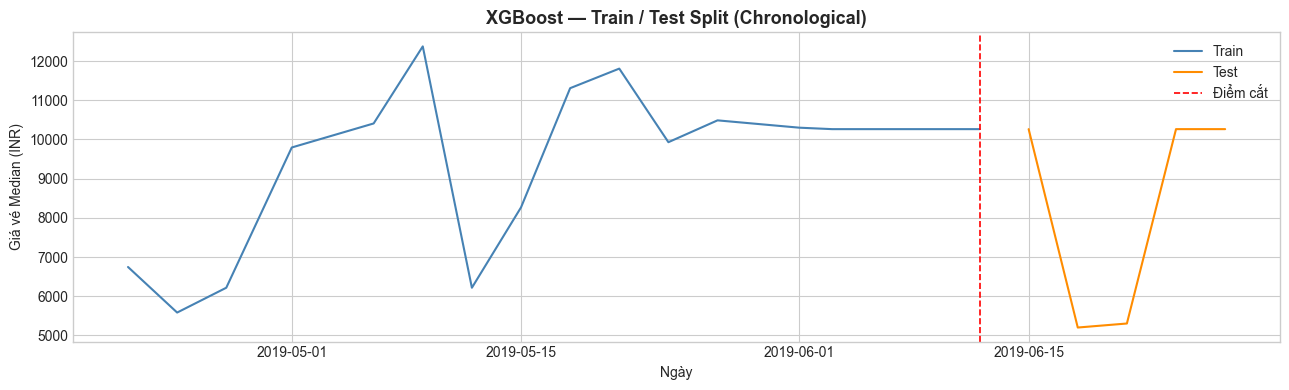

In [20]:
# ── Bước 5: Chronological Train/Test Split ─────────────────────────
FEATURE_COLS = [f'Brent_lag_{LAG_OIL}', f'USD_INR_lag_{LAG_FX}',
                'day_of_week', 'month', 'day_of_month', 'is_weekend']
TARGET_COL   = 'Median_Price'

SPLIT_RATIO_XGB = 0.80
n_xgb     = len(xgb_df)
split_xgb = int(n_xgb * SPLIT_RATIO_XGB)

train_xgb = xgb_df.iloc[:split_xgb].copy()
test_xgb  = xgb_df.iloc[split_xgb:].copy()

X_train = train_xgb[FEATURE_COLS]
y_train = train_xgb[TARGET_COL]
X_test  = test_xgb[FEATURE_COLS]
y_test  = test_xgb[TARGET_COL]

print('═' * 55)
print('  PHÂN CHIA DỮ LIỆU (Chronological Split)')
print('═' * 55)
print(f'  Tổng quan sát   : {n_xgb}')
print(f'  Train (80%)      : {len(train_xgb)} obs  ({train_xgb["Date"].min().date()} → {train_xgb["Date"].max().date()})')
print(f'  Test  (20%)      : {len(test_xgb)} obs  ({test_xgb["Date"].min().date()} → {test_xgb["Date"].max().date()})')
print(f'  Features (X)     : {FEATURE_COLS}')
print(f'  Target   (Y)     : {TARGET_COL}')
print('═' * 55)

# Trực quan hoá điểm cắt
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_xgb['Date'], y_train, color='steelblue', linewidth=1.5, label='Train')
ax.plot(test_xgb['Date'],  y_test,  color='darkorange', linewidth=1.5, label='Test')
ax.axvline(train_xgb['Date'].iloc[-1], color='red', linestyle='--', linewidth=1.2, label='Điểm cắt')
ax.set_title('XGBoost — Train / Test Split (Chronological)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ngày')
ax.set_ylabel('Giá vé Median (INR)')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## Bước 6: Huấn luyện, Đánh giá và "Kể chuyện"

1. **Huấn luyện** XGBoost trên tập Train  
2. **Đánh giá** trên tập Test → RMSE, MAE, MAPE  
3. **So sánh** với kết quả mô hình VAR  
4. **Feature Importance** → biểu đồ xếp hạng mức đóng góp của từng biến

In [21]:
# ── Bước 6a: Huấn luyện XGBoost ───────────────────────────────────
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
print('✓ Mô hình XGBoost đã được huấn luyện thành công!')
print(f'  Số features : {X_train.shape[1]}')
print(f'  Tập train   : {X_train.shape[0]} quan sát')

✓ Mô hình XGBoost đã được huấn luyện thành công!
  Số features : 6
  Tập train   : 17 quan sát


In [22]:
# ── Bước 6b: Dự báo & Đánh giá ────────────────────────────────────
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test.values - y_pred_xgb) / y_test.values)) * 100

print('═' * 55)
print('  KẾT QUẢ ĐÁNH GIÁ — XGBoost')
print('═' * 55)
print(f'  RMSE : {rmse_xgb:>10,.2f} INR')
print(f'  MAE  : {mae_xgb:>10,.2f} INR')
print(f'  MAPE : {mape_xgb:>10.2f} %')
print('═' * 55)

═══════════════════════════════════════════════════════
  KẾT QUẢ ĐÁNH GIÁ — XGBoost
═══════════════════════════════════════════════════════
  RMSE :   3,248.82 INR
  MAE  :   2,113.62 INR
  MAPE :      39.69 %
═══════════════════════════════════════════════════════


In [23]:
# ── Bước 6c: So sánh XGBoost vs VAR ───────────────────────────────
comparison = pd.DataFrame({
    'Metric': ['RMSE (INR)', 'MAE (INR)', 'MAPE (%)'],
    'VAR Model':     [f'{rmse:,.2f}',     f'{mae:,.2f}',     f'{mape:.2f}'],
    'XGBoost Model': [f'{rmse_xgb:,.2f}', f'{mae_xgb:,.2f}', f'{mape_xgb:.2f}']
})

print('\n╔══════════════════════════════════════════════╗')
print('║     SO SÁNH HIỆU SUẤT: VAR vs XGBoost       ║')
print('╚══════════════════════════════════════════════╝\n')
comparison.style.set_caption('So sánh sai số dự báo').set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}]
)


╔══════════════════════════════════════════════╗
║     SO SÁNH HIỆU SUẤT: VAR vs XGBoost       ║
╚══════════════════════════════════════════════╝



,Metric,VAR Model,XGBoost Model
0,RMSE (INR),"5,194.71","3,248.82"
1,MAE (INR),"4,671.78","2,113.62"
2,MAPE (%),57.13,39.69


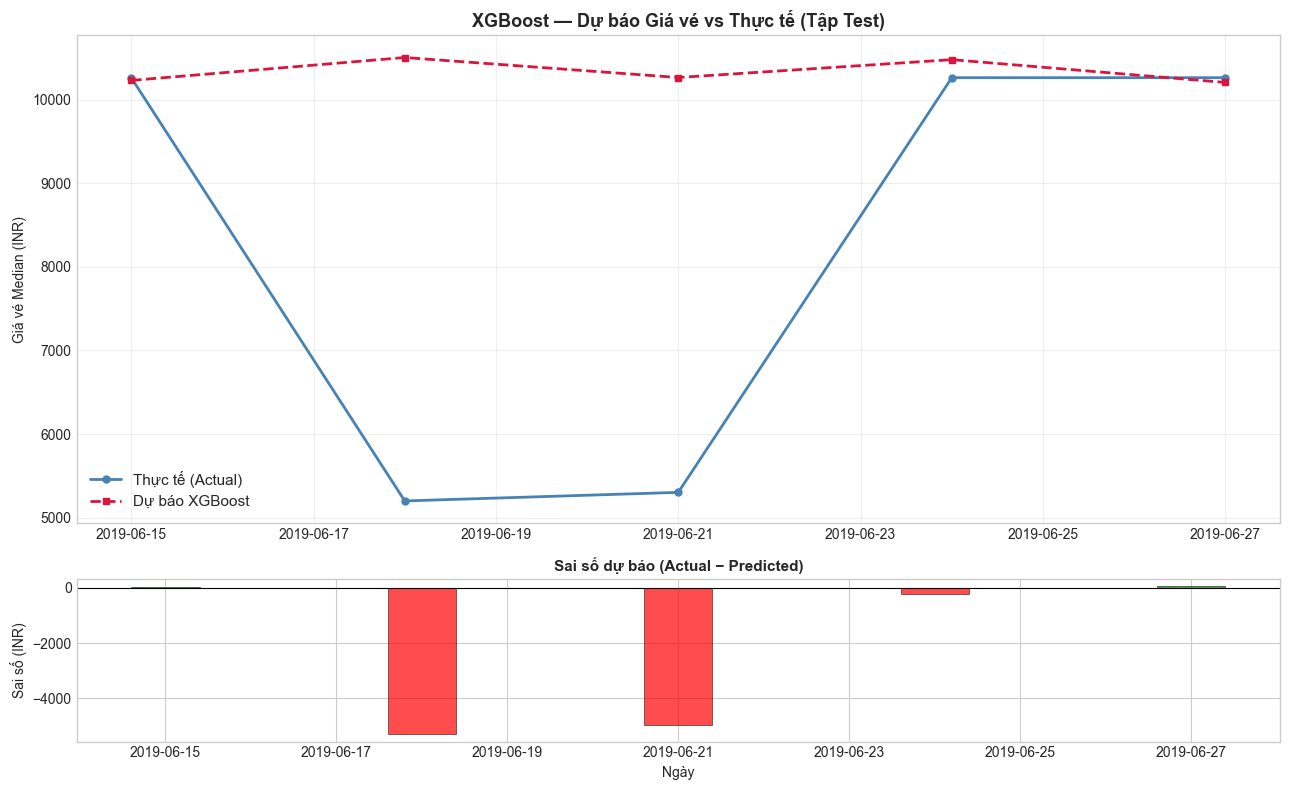

In [24]:
# ── Bước 6d: Biểu đồ Actual vs Predicted ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Giá thực tế vs Dự báo
ax1 = axes[0]
ax1.plot(test_xgb['Date'].values, y_test.values, color='steelblue',
         linewidth=2, marker='o', markersize=5, label='Thực tế (Actual)')
ax1.plot(test_xgb['Date'].values, y_pred_xgb, color='crimson',
         linewidth=2, marker='s', markersize=5, linestyle='--', label='Dự báo XGBoost')
ax1.set_title('XGBoost — Dự báo Giá vé vs Thực tế (Tập Test)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Giá vé Median (INR)')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Sai số (Residuals)
ax2 = axes[1]
residuals = y_test.values - y_pred_xgb
ax2.bar(test_xgb['Date'].values, residuals, color=['green' if r >= 0 else 'red' for r in residuals],
        alpha=0.7, edgecolor='black', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Sai số dự báo (Actual − Predicted)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Sai số (INR)')
ax2.set_xlabel('Ngày')

plt.tight_layout()
plt.savefig('xgb_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

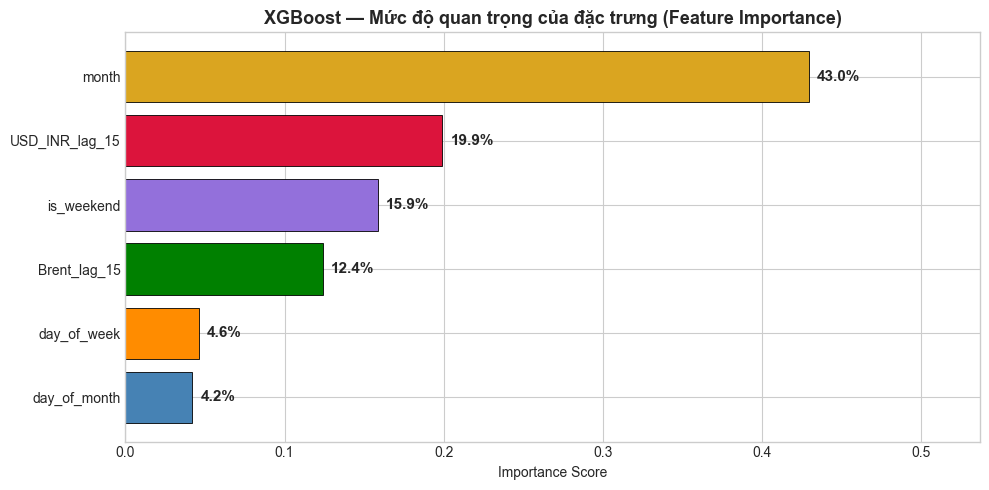


── XẾP HẠNG FEATURE IMPORTANCE ──
  month                     → 43.0%
  USD_INR_lag_15            → 19.9%
  is_weekend                → 15.9%
  Brent_lag_15              → 12.4%
  day_of_week               → 4.6%
  day_of_month              → 4.2%


In [25]:
# ── Bước 6e: Feature Importance — "Vũ khí báo cáo" ───────────────
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=['steelblue', 'darkorange', 'green', 'mediumpurple', 'crimson', 'goldenrod'][:len(feat_imp)],
               edgecolor='black', linewidth=0.6)

# Thêm % trên mỗi thanh
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=11, fontweight='bold')

ax.set_title('XGBoost — Mức độ quan trọng của đặc trưng (Feature Importance)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, max(importances) * 1.25)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── XẾP HẠNG FEATURE IMPORTANCE ──')
for _, row in feat_imp.sort_values('Importance', ascending=False).iterrows():
    print(f'  {row["Feature"]:25s} → {row["Importance"]*100:.1f}%')

## Tổng kết — XGBoost Model

In [26]:
# ── Tổng kết XGBoost ──────────────────────────────────────────────
summary_xgb = pd.DataFrame([
    {'Hạng mục': 'Lag Giá dầu (từ IRF)',     'Giá trị': f'{LAG_OIL} ngày'},
    {'Hạng mục': 'Lag Tỷ giá (từ IRF)',      'Giá trị': f'{LAG_FX} ngày'},
    {'Hạng mục': 'Số features',              'Giá trị': str(len(FEATURE_COLS))},
    {'Hạng mục': 'Train size',               'Giá trị': f'{len(train_xgb)} obs'},
    {'Hạng mục': 'Test size',                'Giá trị': f'{len(test_xgb)} obs'},
    {'Hạng mục': 'RMSE (XGBoost)',           'Giá trị': f'{rmse_xgb:,.2f} INR'},
    {'Hạng mục': 'MAE  (XGBoost)',           'Giá trị': f'{mae_xgb:,.2f} INR'},
    {'Hạng mục': 'MAPE (XGBoost)',           'Giá trị': f'{mape_xgb:.2f} %'},
    {'Hạng mục': 'RMSE (VAR)',               'Giá trị': f'{rmse:,.2f} INR'},
    {'Hạng mục': 'MAE  (VAR)',               'Giá trị': f'{mae:,.2f} INR'},
    {'Hạng mục': 'MAPE (VAR)',               'Giá trị': f'{mape:.2f} %'},
])

print('\n╔══════════════════════════════════════════════╗')
print('║        KẾT QUẢ TỔNG QUAN — XGBoost          ║')
print('╚══════════════════════════════════════════════╝')
summary_xgb.style.set_caption('XGBoost Model Summary').set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}]
)


╔══════════════════════════════════════════════╗
║        KẾT QUẢ TỔNG QUAN — XGBoost          ║
╚══════════════════════════════════════════════╝


,Hạng mục,Giá trị
0,Lag Giá dầu (từ IRF),15 ngày
1,Lag Tỷ giá (từ IRF),15 ngày
2,Số features,6
3,Train size,17 obs
4,Test size,5 obs
5,RMSE (XGBoost),"3,248.82 INR"
6,MAE (XGBoost),"2,113.62 INR"
7,MAPE (XGBoost),39.69 %
8,RMSE (VAR),"5,194.71 INR"
9,MAE (VAR),"4,671.78 INR"
